<a href="https://colab.research.google.com/github/Priya-Saini-1/DataScience_Grras/blob/main/CarPricePridiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Car Price Prediction***

Import Libraries

In [134]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save the trained model
import joblib

# Download dataset from GitHub
import urllib.request
import os

In [135]:
# ==========================================
# Download Dataset from GitHub
# ==========================================

download_dir = "./data/"

download_url = "https://raw.githubusercontent.com/manishkr1754/CarDekho_Used_Car_Price_Prediction/main/notebooks/data/cardekho_dataset.csv"

os.makedirs(download_dir, exist_ok=True)

filename = os.path.basename(download_url)

download_file_path = os.path.join(download_dir, filename)

urllib.request.urlretrieve(download_url, download_file_path)

print("Dataset Downloaded Successfully!")
print("Saved at:", download_file_path)

Dataset Downloaded Successfully!
Saved at: ./data/cardekho_dataset.csv


In [136]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(download_file_path)

print("Dataset Loaded Successfully!\n")

df.head()

Dataset Loaded Successfully!



,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [137]:
# ==========================================
# Basic Information
# ==========================================

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of Dataset: (15411, 14)

Column Names:
Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine            

In [138]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [139]:
# ==========================================
# Missing Values
# ==========================================

print(df.isnull().sum())

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


In [140]:
# ==========================================
# Display Dataset
# ==========================================

print("First 5 Records")
display(df.head())

print("\nLast 5 Records")
display(df.tail())

First 5 Records


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Last 5 Records


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [141]:
# ==========================================
# Check Duplicate Values
# ==========================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Records:", duplicates)

Number of Duplicate Records: 0


In [142]:
# ==========================================
# Unique Values
# ==========================================

for column in df.columns:
    print(f"{column} : {df[column].nunique()} unique values")

Unnamed: 0 : 15411 unique values
car_name : 121 unique values
brand : 32 unique values
model : 120 unique values
vehicle_age : 24 unique values
km_driven : 3688 unique values
seller_type : 3 unique values
fuel_type : 5 unique values
transmission_type : 2 unique values
mileage : 411 unique values
engine : 110 unique values
max_power : 342 unique values
seats : 8 unique values
selling_price : 1086 unique values


In [143]:
# ==========================================
# Top 10 Car Brands
# ==========================================

brand_count = df["brand"].value_counts()

print(brand_count.head(10))

brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64


In [144]:
# ==========================================
# Fuel Type Distribution
# ==========================================

fuel_count = df["fuel_type"].value_counts()

print(fuel_count)

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64


In [145]:
# ==========================================
# Seller Type Distribution
# ==========================================

seller_count = df["seller_type"].value_counts()

print(seller_count)

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64


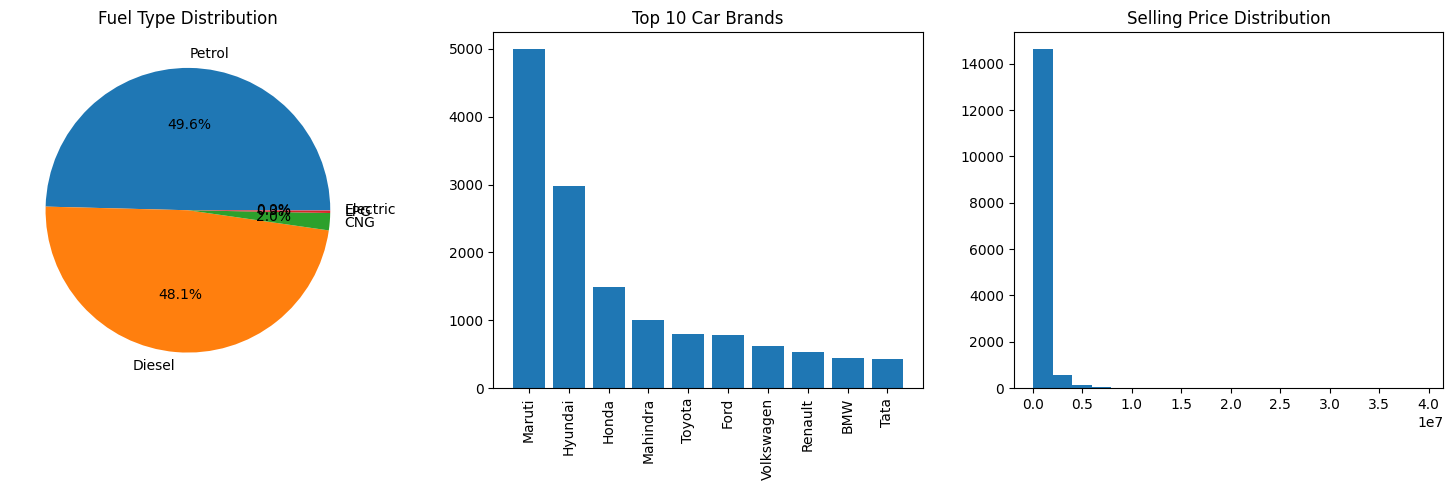

In [146]:
# ==========================================
# Data Visualization
# ==========================================

plt.figure(figsize=(15,5))

# -------------------------
# Pie Chart
# -------------------------

plt.subplot(1,3,1)

plt.pie(
    fuel_count,
    labels=fuel_count.index,
    autopct="%1.1f%%"
)

plt.title("Fuel Type Distribution")


# -------------------------
# Bar Chart
# -------------------------

plt.subplot(1,3,2)

plt.bar(
    brand_count.head(10).index,
    brand_count.head(10).values
)

plt.xticks(rotation=90)

plt.title("Top 10 Car Brands")


# -------------------------
# Histogram
# -------------------------

plt.subplot(1,3,3)

plt.hist(df["selling_price"], bins=20)

plt.title("Selling Price Distribution")

plt.tight_layout()

plt.show()

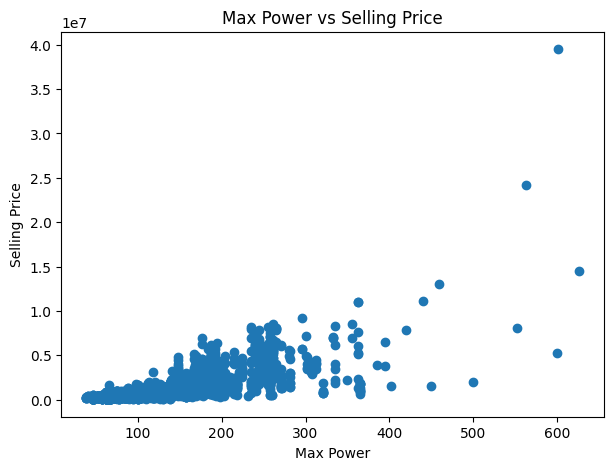

In [147]:
# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(7,5))

plt.scatter(
    df["max_power"],
    df["selling_price"]
)

plt.xlabel("Max Power")

plt.ylabel("Selling Price")

plt.title("Max Power vs Selling Price")

plt.show()

In [148]:
# ==========================================
# Select Features for Machine Learning
# ==========================================

df_model = df.copy()

# Drop unnecessary columns
df_model.drop(["Unnamed: 0", "car_name", "model"], axis=1, inplace=True)

print(df_model.head())

     brand  vehicle_age  km_driven seller_type fuel_type transmission_type  \
0   Maruti            9     120000  Individual    Petrol            Manual   
1  Hyundai            5      20000  Individual    Petrol            Manual   
2  Hyundai           11      60000  Individual    Petrol            Manual   
3   Maruti            9      37000  Individual    Petrol            Manual   
4     Ford            6      30000      Dealer    Diesel            Manual   

   mileage  engine  max_power  seats  selling_price  
0    19.70     796      46.30      5         120000  
1    18.90    1197      82.00      5         550000  
2    17.00    1197      80.00      5         215000  
3    20.92     998      67.10      5         226000  
4    22.77    1498      98.59      5         570000  


In [149]:
# ==========================================
# Label Encoding
# ==========================================

le_brand = LabelEncoder()
le_seller = LabelEncoder()
le_fuel = LabelEncoder()
le_transmission = LabelEncoder()

df_model["brand"] = le_brand.fit_transform(df_model["brand"])
df_model["seller_type"] = le_seller.fit_transform(df_model["seller_type"])
df_model["fuel_type"] = le_fuel.fit_transform(df_model["fuel_type"])
df_model["transmission_type"] = le_transmission.fit_transform(df_model["transmission_type"])

In [150]:
# ==========================================
# Features and Target
# ==========================================

X = df_model.drop("selling_price", axis=1)

y = df_model["selling_price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (15411, 10)
Target Shape: (15411,)


In [151]:
# ==========================================
# Features and Target
# ==========================================

X = df_model.drop("selling_price", axis=1)

y = df_model["selling_price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (15411, 10)
Target Shape: (15411,)


In [152]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [153]:
# ==========================================
# Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (12328, 10)
Testing Data : (3083, 10)


In [154]:
# ==========================================
# Train Linear Regression Model
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [155]:
# ==========================================
# Predict on Test Data
# ==========================================

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,190000,9.823687e+03
1,600000,5.730721e+05
2,665000,4.871317e+05
3,1570000,1.471595e+06
4,160000,-4.409128e+05
5,675000,1.112593e+06
6,465000,4.084950e+05
7,260000,3.563798e+05
8,300000,7.286003e+05
9,850000,1.781914e+06


In [156]:
# ==========================================
# Evaluate Model
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-"*40)
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Model Performance
----------------------------------------
Mean Absolute Error : 278522.2731811379
Mean Squared Error  : 253033406576.87653
Root Mean Squared Error : 503024.2604257537
R2 Score : 0.6638688531314566


In [157]:
# ==========================================
# Predict Selling Price of a New Car
# ==========================================

new_data = pd.DataFrame({
    "brand": ["Maruti"],
    "vehicle_age": [3],
    "km_driven": [25000],
    "seller_type": ["Individual"],
    "fuel_type": ["Petrol"],
    "transmission_type": ["Manual"],
    "mileage": [22.5],
    "engine": [1197],
    "max_power": [82.0],
    "seats": [5]
})

In [158]:
# Encode categorical columns

new_data["brand"] = le_brand.transform(new_data["brand"])
new_data["seller_type"] = le_seller.transform(new_data["seller_type"])
new_data["fuel_type"] = le_fuel.transform(new_data["fuel_type"])
new_data["transmission_type"] = le_transmission.transform(new_data["transmission_type"])

In [159]:
# Scale new data

new_data = scaler.transform(new_data)

# Predict price

prediction = model.predict(new_data)

print("Predicted Selling Price: ₹", round(prediction[0], 2))

Predicted Selling Price: ₹ 700301.49


In [160]:
# ==========================================
# Save Trained Model
# ==========================================

joblib.dump(model, "car_price_model.joblib")

print("Model saved successfully!")

Model saved successfully!
